In [ ]:
# --- Setup: preload DAM, load KB ---
import sys, time
from pathlib import Path
sys.path.insert(0, "..")

from hanoi_caption.dam_model import MODEL_NAME as DAM_NAME
from hanoi_caption.kb_loader import load_kb
from hanoi_caption.model_registry import registry

nodes = load_kb("../data/kb.json")
print(f"KB ready: {len(nodes)} nodes")

t0 = time.perf_counter()
registry.get(DAM_NAME)
print(f"DAM loaded in {time.perf_counter()-t0:.1f}s")


In [1]:
from hanoi_caption.kb_loader import load_kb
nodes = load_kb("../data/kb.json")
print(f"KB ready: {len(nodes)} nodes")

KB ready: 181 nodes


In [2]:
# --- Segment-only debug: run retrieval once, skip DAM ---
# Useful for tuning smooth_window / min_segment_seconds without paying the DAM cost.
from pathlib import Path

from hanoi_caption.kb_loader import index_by_kb_id
from hanoi_caption.video_pipeline import extract_frame_records

VIDEO_PATH = Path("../tests/fixtures/video/A39_217_HTTLCoHieu_M_T01.MOV")

sampled, records, stride_s = extract_frame_records(
    video_path=VIDEO_PATH,
    kb_nodes=nodes,
    dino_index_path="../data/cache/dino_faiss.index",
    id_map_path="../data/cache/id_map.json",
    sample_fps=1.0,
)
nodes_by_kb_id = index_by_kb_id(nodes)
print(f"{len(records)} frames sampled; stride_s={stride_s}s\n")
for r in records:
    name = nodes_by_kb_id[r.kb_id].name_en if r.kb_id in nodes_by_kb_id else "-"
    print(f"  t={r.timestamp_s:6.2f}s   kb_id={str(r.kb_id):25}   score={r.score:.3f}   {name}")


Using device: cuda


61 frames sampled; stride_s=1.0s

  t=  0.00s   kb_id=flag_tower_of_hanoi         score=0.836   Flag Tower of Hanoi
  t=  1.00s   kb_id=flag_tower_of_hanoi         score=0.847   Flag Tower of Hanoi
  t=  2.00s   kb_id=flag_tower_of_hanoi         score=0.847   Flag Tower of Hanoi
  t=  3.00s   kb_id=flag_tower_of_hanoi         score=0.828   Flag Tower of Hanoi
  t=  4.00s   kb_id=flag_tower_of_hanoi         score=0.823   Flag Tower of Hanoi
  t=  5.00s   kb_id=flag_tower_of_hanoi         score=0.817   Flag Tower of Hanoi
  t=  6.00s   kb_id=flag_tower_of_hanoi         score=0.837   Flag Tower of Hanoi
  t=  7.00s   kb_id=flag_tower_of_hanoi         score=0.840   Flag Tower of Hanoi
  t=  8.00s   kb_id=flag_tower_of_hanoi         score=0.823   Flag Tower of Hanoi
  t=  9.00s   kb_id=flag_tower_of_hanoi         score=0.829   Flag Tower of Hanoi
  t= 10.00s   kb_id=flag_tower_of_hanoi         score=0.835   Flag Tower of Hanoi
  t= 11.00s   kb_id=flag_tower_of_hanoi         score=0.831   Fl

smooth_window=8  min_segment_seconds=2.0s  ->  1 segment(s)

    0.00s ->  61.00s   Flag Tower of Hanoi              conf=0.778   frames=61


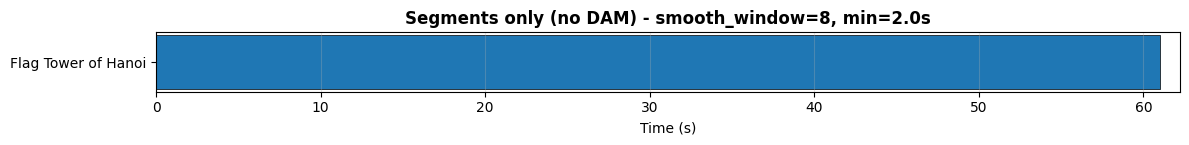

In [6]:
# --- Tweak smoothing params, re-segment, plot timeline (no retrieval rerun) ---
import matplotlib.pyplot as plt

from hanoi_caption.video_pipeline import smooth_and_group

SMOOTH_WINDOW = 8
MIN_SEGMENT_SECONDS = 2.0

segs = smooth_and_group(
    records,
    smooth_window=SMOOTH_WINDOW,
    min_segment_seconds=MIN_SEGMENT_SECONDS,
    stride_s=stride_s,
)
print(f"smooth_window={SMOOTH_WINDOW}  min_segment_seconds={MIN_SEGMENT_SECONDS}s  ->  {len(segs)} segment(s)\n")
for s in segs:
    name = nodes_by_kb_id[s["kb_id"]].name_en if s["kb_id"] in nodes_by_kb_id else s["kb_id"]
    print(f"  {s['start_s']:6.2f}s -> {s['end_s']:6.2f}s   {name:30}   conf={s['confidence']:.3f}   frames={len(s['frame_indices'])}")

if segs:
    seen = {s["kb_id"]: (nodes_by_kb_id[s["kb_id"]].name_en if s["kb_id"] in nodes_by_kb_id else s["kb_id"])
            for s in segs}
    unique = list(seen.keys())
    cmap = plt.get_cmap("tab10")
    fig, ax = plt.subplots(figsize=(12, 1.0 + 0.55 * len(unique)))
    for i, kb in enumerate(unique):
        spans = [(s["start_s"], s["end_s"] - s["start_s"]) for s in segs if s["kb_id"] == kb]
        ax.broken_barh(spans, (i - 0.4, 0.8),
                       facecolors=cmap(i % 10), edgecolor="black", linewidth=0.5)
    ax.set_yticks(range(len(unique)))
    ax.set_yticklabels([seen[k] for k in unique])
    ax.invert_yaxis()
    ax.set_xlabel("Time (s)")
    ax.set_xlim(0, max(s["end_s"] for s in segs) * 1.02)
    ax.set_title(f"Segments only (no DAM) - smooth_window={SMOOTH_WINDOW}, min={MIN_SEGMENT_SECONDS}s",
                 fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
# --- Video pipeline demo: run caption_video on a real clip ---
import time
from pathlib import Path

from hanoi_caption.video_pipeline import caption_video

VIDEO_PATH = Path("../tests/fixtures/video/A39_203_HTTLCongDoanMonTrai_M_T02.MOV")

if not VIDEO_PATH.exists():
    print(f"Drop a video at: {VIDEO_PATH.resolve()}")
    print("(A 10-60s walking-tour clip showing 1-3 Hanoi landmarks works well.)")
    segments = []
else:
    print(f"Processing {VIDEO_PATH.name} ...")
    t0 = time.perf_counter()
    segments = caption_video(
        video_path=VIDEO_PATH,
        kb_nodes=nodes,
        dino_index_path="../data/cache/dino_faiss.index",
        id_map_path="../data/cache/id_map.json",
        sample_fps=1.0,
        smooth_window=3,
        min_segment_seconds=2.0,
        dam_frame_budget=(4, 8),
    )
    elapsed = time.perf_counter() - t0
    print(f"Done in {elapsed:.1f}s -> {len(segments)} segment(s)")


In [ ]:
# --- Render segments: timeline plot + caption list ---
import matplotlib.pyplot as plt

if not segments:
    print("No segments to render. Run the previous cell first.")
else:
    # Unique landmarks in order of appearance.
    seen = {}
    for s in segments:
        if s.kb_id not in seen:
            seen[s.kb_id] = s.name_en
    unique_kb_ids = list(seen.keys())
    cmap = plt.get_cmap("tab10")
    color_by_kb_id = {kb_id: cmap(i % 10) for i, kb_id in enumerate(unique_kb_ids)}

    # Timeline: one row per landmark, broken_barh shows segment spans.
    fig, ax = plt.subplots(figsize=(12, 1.0 + 0.55 * len(unique_kb_ids)))
    for i, kb_id in enumerate(unique_kb_ids):
        spans = [(s.start_s, s.end_s - s.start_s) for s in segments if s.kb_id == kb_id]
        ax.broken_barh(spans, (i - 0.4, 0.8),
                       facecolors=color_by_kb_id[kb_id], edgecolor="black", linewidth=0.5)

    ax.set_yticks(range(len(unique_kb_ids)))
    ax.set_yticklabels([seen[k] for k in unique_kb_ids])
    ax.invert_yaxis()  # first landmark on top
    ax.set_xlabel("Time (s)")
    ax.set_xlim(0, max(s.end_s for s in segments) * 1.02)
    ax.set_title(f"Landmark segments in {VIDEO_PATH.name}", fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Captions list.
    for i, s in enumerate(segments, 1):
        print("=" * 80)
        print(f"Segment {i}: {s.start_s:.1f}s - {s.end_s:.1f}s  ({s.end_s - s.start_s:.1f}s)")
        print(f"Landmark : {s.name_en}  (confidence {s.confidence:.3f})")
        print(f"Frames   : {s.debug.get('frames_sampled', '?')}/{s.debug.get('frames_total', '?')}  "
              f"DAM: {s.debug.get('timings', {}).get('dam_caption', 0):.1f}s")
        print("-" * 80)
        print(s.caption)
    print("=" * 80)
